In [1]:
## TO RUN ON THE CLOUD 

## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


# Summary

At this notebook:
- Handles multiple dataset creations, relabel some labels.
- Show how dense features of Dinov3 can be perceived over different input dimensions (512,1024,2048).
- Evaluate the impact of tilling the full-images into tiles of 512,1024 or 2048. 
- Compute full embeddings and patch embedding of three datasets( NC, WP and UM test)
- Compute the visualization of the datasets and generate nice plots for the thesis. 

In [2]:
fo.list_datasets(
    
)

['FLPLAN', 'flplan200', 'flplanpatches', 'nc765', 'wp125']

In [9]:
dataset = fo.load_dataset("nc765")

In [10]:
dataset

Name:        nc765
Media type:  image
Num samples: 716
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    thumbnail_path:   fiftyone.core.fields.StringField
    ground_truthv2:   fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)

In [15]:
dataset.count_values('ground_truth.detections.label')

{'dugong': 3546}

In [14]:
dataset

Name:        wp125
Media type:  image
Num samples: 152
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    thumbnail_path:   fiftyone.core.fields.StringField
    roigrid_512_250:  fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    roigrid_1024_250: fiftyone.core.fields.EmbeddedDocumentField

In [12]:
dataset.count_values('ground_truthv2.detections.label')

{'calf': 79, 'dugong': 183}

### Rename the label Dugong to dugong

In [11]:
for sample in dataset.iter_samples(autosave=True, progress=True):
    if not sample.ground_truthv2 or not sample.ground_truthv2.detections:
        continue
    for det in sample.ground_truthv2.detections:
        det.label = det.label.lower()
    
    sample.save()

 100% |█████████████████| 152/152 [7.9s elapsed, 0s remaining, 18.4 samples/s]      


In [7]:

session = fo.launch_app(dataset,
                        auto=False,
                        port=5151)

Session launched. Run `session.show()` to open the App in a cell output.


In [16]:
session.refresh()

In [12]:
session.selected

['6a303cf33e03af1d71b350a9',
 '6a303cf33e03af1d71b350b5',
 '6a303cf33e03af1d71b350c4',
 '6a303cf33e03af1d71b350ef']

In [14]:
dataset

Name:        WP_125
Media type:  image
Num samples: 152
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)

In [16]:
dataset.count_values("mission_name")

{'GAM': 27, 'FRIWEN': 63, 'MANTASANDY': 3, 'UM': 59}

In [17]:
dataset.values("filepath")

['/share/home/e2406743/dataset/wp_improved/new_WP/MANTASANDY/MANTASANDY_M5/images/FPLAN_P4P_MANTASANDY_M5_GSPzip-6495ab5e293b6_4.jpeg',
 '/share/home/e2406743/dataset/wp_improved/new_WP/MANTASANDY/MANTASANDY_M5/images/FPLAN_P4P_MANTASANDY_M5_GSPzip-6495ab5e293b6_5.jpeg',
 '/share/home/e2406743/dataset/wp_improved/new_WP/MANTASANDY/MANTASANDY_M5/images/FPLAN_P4P_MANTASANDY_M5_GSPzip-6495ab5e293b6_18.jpeg',
 '/share/home/e2406743/dataset/wp_improved/new_WP/GAM/GAM_M10/images/MAN_P4_GAM_M10_F3_GSP_DJI_0112-66acd85262429_138.jpeg',
 '/share/home/e2406743/dataset/wp_improved/new_WP/GAM/GAM_M10/images/MAN_P4_GAM_M10_F3_GSP_DJI_0112-66acd85262429_123.jpeg',
 '/share/home/e2406743/dataset/wp_improved/new_WP/GAM/GAM_M10/images/MAN_P4_GAM_M10_F3_GSP_DJI_0112-66acd85262429_72.jpeg',
 '/share/home/e2406743/dataset/wp_improved/new_WP/GAM/GAM_M10/images/MAN_P4_GAM_M10_F3_GSP_DJI_0112-66acd85262429_133.jpeg',
 '/share/home/e2406743/dataset/wp_improved/new_WP/GAM/GAM_M1/images/MAN_P4_GAM_M1_F2_GSP_DJI

# Analysing cosine similarity with a Dinov3

In [ ]:
from dotenv import load_dotenv
load_dotenv()

import fiftyone.utils.torch as fout
from huggingface_hub import login

if "HUGGING_FACE_API" in os.environ:
    login(token=os.environ["HUGGING_FACE_API"])

In [14]:
from transformers import AutoImageProcessor, AutoModel

MODEL_ID  = "facebook/dinov3-vitl16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model     = AutoModel.from_pretrained(MODEL_ID)



Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

In [16]:

from transformers import AutoImageProcessor, AutoModel
import fiftyone.utils.transformers as fout

MODEL_ID  = "facebook/dinov3-vitl16-pretrain-lvd1689m"


processor = AutoImageProcessor.from_pretrained(MODEL_ID)

print("=== Processor defaults ===")
print(f"  do_resize        : {processor.do_resize}")
print(f"  size             : {processor.size}")
print(f"  default_to_square: {processor.default_to_square}")
print(f"  do_rescale       : {processor.do_rescale}")
print(f"  do_normalize     : {processor.do_normalize}")
print(f"  image_mean       : {processor.image_mean}")
print(f"  image_std        : {processor.image_std}")

# ── Disable resize so OUR crop reaches the model untouched ───────────────────
# We keep rescale (0→1 float) and normalize (ImageNet stats) since those
# are independent of spatial dimensions and DINOv2 always expects them.
processor.do_resize = False
processor.default_to_square = False   # defensive — has no effect if do_resize=False

print("\n=== Processor after patch ===")
print(f"  do_resize        : {processor.do_resize}")
print(f"  default_to_square: {processor.default_to_square}")
print(f"  do_rescale       : {processor.do_rescale}   ← kept ON")
print(f"  do_normalize     : {processor.do_normalize}  ← kept ON")

# ── Sanity check: what does the processor produce for a known input size? ────
from PIL import Image
import numpy as np

STRIDE      = 16
TEST_SIZE   = 512    # one of our intended crop sizes

dummy = Image.fromarray(np.zeros((TEST_SIZE, TEST_SIZE, 3), dtype=np.uint8))
out   = processor(images=dummy, return_tensors="pt")
tensor_shape = out["pixel_values"].shape   # (1, 3, H, W)

print(f"\n=== Sanity check (dummy {TEST_SIZE}×{TEST_SIZE} input) ===")
print(f"  pixel_values shape : {tuple(tensor_shape)}")
print(f"  Expected           : (1, 3, {TEST_SIZE}, {TEST_SIZE})")

expected_tokens = (TEST_SIZE // STRIDE) ** 2
print(f"  Expected patch tokens (stride {STRIDE}): {expected_tokens}  "
      f"({TEST_SIZE//STRIDE}×{TEST_SIZE//STRIDE} grid)")

assert tensor_shape[-2] == TEST_SIZE and tensor_shape[-1] == TEST_SIZE, (
    f"Processor is still resizing! Got {tuple(tensor_shape)}, "
    f"expected (1, 3, {TEST_SIZE}, {TEST_SIZE}). Check do_resize."
)
print("\n  Processor is correctly passing the image through at native resolution.")

# ── Load model ────────────────────────────────────────────────────────────────
base_model = AutoModel.from_pretrained(MODEL_ID)
model      = fout.convert_transformers_model(base_model, image_processor=processor)

print(f"\nModel loaded: {MODEL_ID}")
print(f"  fout model type: {type(model)}")

=== Processor defaults ===
  do_resize        : True
  size             : {'height': 224, 'width': 224}
  default_to_square: True
  do_rescale       : True
  do_normalize     : True
  image_mean       : [0.485, 0.456, 0.406]
  image_std        : [0.229, 0.224, 0.225]

=== Processor after patch ===
  do_resize        : False
  default_to_square: False
  do_rescale       : True   ← kept ON
  do_normalize     : True  ← kept ON

=== Sanity check (dummy 512×512 input) ===
  pixel_values shape : (1, 3, 512, 512)
  Expected           : (1, 3, 512, 512)
  Expected patch tokens (stride 16): 1024  (32×32 grid)

  Processor is correctly passing the image through at native resolution.


Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]


Model loaded: facebook/dinov3-vitl16-pretrain-lvd1689m
  fout model type: <class 'fiftyone.utils.transformers.FiftyOneTransformer'>


In [17]:
# ── Cell 2 (revised): Model Audit — use base_model directly on correct device ─
import torch
import numpy as np
from PIL import Image

STRIDE    = 16
TEST_SIZE = 512
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")

# ── Drop the fout wrapper — use base_model directly ──────────────────────────
# FiftyOneTransformer is designed for FiftyOne's .predict()/.embed() pipeline,
# not for raw tensor inference. base_model gives us full control over outputs.
base_model.to(DEVICE)
base_model.eval()
print(f"base_model on device: {next(base_model.parameters()).device}")

# ── Probe: raw pixel_values tensor, correct device ───────────────────────────
print(f"\n=== Probe: base_model + processor, input {TEST_SIZE}×{TEST_SIZE} ===")

dummy  = Image.fromarray(np.zeros((TEST_SIZE, TEST_SIZE, 3), dtype=np.uint8))
inputs = processor(images=dummy, return_tensors="pt")
inputs = {k: v.to(DEVICE) for k, v in inputs.items()}   # ← move to GPU

print(f"  pixel_values dtype : {inputs['pixel_values'].dtype}")
print(f"  pixel_values device: {inputs['pixel_values'].device}")
print(f"  pixel_values shape : {tuple(inputs['pixel_values'].shape)}")

try:
    with torch.no_grad():
        out = base_model(**inputs, output_hidden_states=False)

    hidden      = out.last_hidden_state          # (1, 1 + n_reg + n_patches, dim)
    n_total     = hidden.shape[1]
    n_patches   = (TEST_SIZE // STRIDE) ** 2
    n_registers = n_total - 1 - n_patches        # auto-detect registers

    print(f"\n  last_hidden_state shape : {tuple(hidden.shape)}")
    print(f"  Total tokens            : {n_total}")
    print(f"  = 1 CLS + {n_registers} registers + {n_patches} patch tokens")
    print(f"  Embedding dim           : {hidden.shape[-1]}")
    print(f"  Patch token shape       : ({n_patches}, {hidden.shape[-1]})")
    print(f"\n  base_model works correctly: YES")

    # Store for downstream cells
    N_REGISTERS = n_registers
    EMBED_DIM   = hidden.shape[-1]

except Exception as e:
    print(f"  FAILED: {e}")
    raise

print(f"\n=== Constants locked for downstream cells ===")
print(f"  DEVICE      = {DEVICE}")
print(f"  STRIDE      = {STRIDE}")
print(f"  N_REGISTERS = {N_REGISTERS}")
print(f"  EMBED_DIM   = {EMBED_DIM}")

Device: cuda
base_model on device: cuda:0

=== Probe: base_model + processor, input 512×512 ===
  pixel_values dtype : torch.float32
  pixel_values device: cuda:0
  pixel_values shape : (1, 3, 512, 512)

  last_hidden_state shape : (1, 1029, 1024)
  Total tokens            : 1029
  = 1 CLS + 4 registers + 1024 patch tokens
  Embedding dim           : 1024
  Patch token shape       : (1024, 1024)

  base_model works correctly: YES

=== Constants locked for downstream cells ===
  DEVICE      = cuda
  STRIDE      = 16
  N_REGISTERS = 4
  EMBED_DIM   = 1024


# Functions for analysing dense feature map

In [18]:
#Data Loading & Crop Geometry 
import numpy as np
from PIL import Image
from pathlib import Path


# Group 1: Data Loading

def load_sample(dataset: fo.Dataset, identifier: str) -> fo.Sample:
    """
    Load a FiftyOne sample by sample_id or filepath.

    Parameters
    ----------
    dataset    : fo.Dataset
    identifier : sample_id string OR absolute filepath string

    Returns
    -------
    fo.Sample
    """
    # Try as sample_id first
    try:
        sample = dataset[identifier]
        print(f"Loaded by sample_id : {identifier}")
        return sample
    except KeyError:
        pass

    # Fall back to filepath
    view = dataset.match(fo.ViewField("filepath") == identifier)
    if len(view) == 0:
        raise ValueError(
            f"No sample found for identifier '{identifier}'. "
            "Provide a valid sample_id or filepath."
        )
    sample = view.first()
    print(f"Loaded by filepath  : {Path(identifier).name}")
    return sample


def get_centroid_pixels(sample: fo.Sample) -> tuple:
    """
    Extract the centroid of the largest ground_truth detection
    in absolute pixel coordinates.

    Parameters
    ----------
    sample : fo.Sample  — must have metadata and ground_truth populated

    Returns
    -------
    cx, cy      : float  — centroid in absolute pixels
    detection   : fo.Detection — the chosen detection (for bbox drawing later)
    img_w, img_h: int    — original image dimensions
    """
    if not sample.ground_truth or not sample.ground_truth.detections:
        raise ValueError(f"Sample {sample.id} has no ground_truth detections.")

    img_w = sample.metadata.width
    img_h = sample.metadata.height

    # Pick largest detection by bbox area
    det = max(
        sample.ground_truth.detections,
        key=lambda d: d.bounding_box[2] * d.bounding_box[3]
    )

    bx, by, bw, bh = det.bounding_box   # normalised [0,1] FiftyOne format
    cx = (bx + bw / 2) * img_w
    cy = (by + bh / 2) * img_h

    print(f"Image size          : {img_w} × {img_h} px")
    print(f"Largest detection   : label='{det.label}'  "
          f"bbox=[{bx:.4f}, {by:.4f}, {bw:.4f}, {bh:.4f}]")
    print(f"Centroid (absolute) : ({cx:.1f}, {cy:.1f}) px")

    return cx, cy, det, img_w, img_h


# ── Group 2: Crop Geometry ────────────────────────────────────────────────────

def compute_crop_window(
    cx: float, cy: float,
    crop_size: int,
    img_w: int, img_h: int,
) -> tuple:
    """
    Compute a crop_size × crop_size window centered on (cx, cy),
    sliding inward if the window overflows any image edge.
    Never pads — always stays within image boundaries.

    Parameters
    ----------
    cx, cy    : centroid in absolute pixels
    crop_size : desired square crop side length in pixels
    img_w     : image width  in pixels
    img_h     : image height in pixels

    Returns
    -------
    x0, y0, x1, y1 : int — top-left and bottom-right pixel coordinates
    shifted         : bool — True if the window was slid from centre
    """
    if crop_size > img_w or crop_size > img_h:
        raise ValueError(
            f"crop_size {crop_size} exceeds image dimensions {img_w}×{img_h}. "
            "Choose a smaller crop size for this image."
        )

    half = crop_size // 2

    # Start centered
    x0 = int(cx) - half
    y0 = int(cy) - half
    x1 = x0 + crop_size
    y1 = y0 + crop_size

    # Slide horizontally if needed
    if x0 < 0:
        x1 -= x0   # shift right
        x0  = 0
    elif x1 > img_w:
        x0 -= (x1 - img_w)   # shift left
        x1  = img_w

    # Slide vertically if needed
    if y0 < 0:
        y1 -= y0   # shift down
        y0  = 0
    elif y1 > img_h:
        y0 -= (y1 - img_h)   # shift up
        y1  = img_h

    shifted = not (abs(int(cx) - half - x0) < 1 and abs(int(cy) - half - y0) < 1)

    return x0, y0, x1, y1, shifted


def remap_centroid_to_crop(
    cx: float, cy: float,
    x0: int,   y0: int,
) -> tuple:
    """
    Recompute centroid coordinates relative to the crop's top-left corner.

    Parameters
    ----------
    cx, cy : centroid in original image absolute pixels
    x0, y0 : crop top-left in original image pixels

    Returns
    -------
    cx_crop, cy_crop : float — centroid within the crop coordinate space
    """
    return cx - x0, cy - y0


# ── Group 3: Token Space ──────────────────────────────────────────────────────

def get_token_grid_shape(crop_size: int, stride: int) -> tuple:
    """
    Returns (grid_h, grid_w) — the token grid dimensions for a square crop.

    Parameters
    ----------
    crop_size : side length of the square crop in pixels
    stride    : ViT patch stride (14 or 16)

    Returns
    -------
    grid_h, grid_w : int
    """
    grid = crop_size // stride
    return grid, grid


def pixels_to_token(
    px: float, py: float,
    stride: int,
    grid_h: int, grid_w: int,
) -> tuple:
    """
    Map a pixel position within a crop to its token grid index.
    Clamps to valid grid bounds.

    Parameters
    ----------
    px, py   : pixel position within the crop
    stride   : ViT patch stride
    grid_h   : token grid height
    grid_w   : token grid width

    Returns
    -------
    token_row, token_col : int
    """
    col = int(px / stride)
    row = int(py / stride)
    col = max(0, min(grid_w - 1, col))
    row = max(0, min(grid_h - 1, row))
    return row, col


# ── Smoke test ────────────────────────────────────────────────────────────────

def _smoke_test_geometry(crop_sizes: list[int], stride: int = STRIDE):
    print("=== Geometry smoke test ===\n")
    # Simulate a 4000×3000 image with centroid near the left edge
    img_w, img_h = 4000, 3000
    cx, cy = 300.0, 1500.0   # near left edge — forces a rightward slide

    print(f"Simulated image  : {img_w}×{img_h}  centroid=({cx},{cy})\n")

    for cs in crop_sizes:
        x0, y0, x1, y1, shifted = compute_crop_window(cx, cy, cs, img_w, img_h)
        cx_c, cy_c              = remap_centroid_to_crop(cx, cy, x0, y0)
        grid_h, grid_w          = get_token_grid_shape(cs, stride)
        tok_row, tok_col        = pixels_to_token(cx_c, cy_c, stride, grid_h, grid_w)

        print(f"  crop {cs:>4}px : window=({x0},{y0})→({x1},{y1})  "
              f"slid={'YES' if shifted else 'no '}  "
              f"centroid-in-crop=({cx_c:.1f},{cy_c:.1f})  "
              f"grid={grid_h}×{grid_w}  "
              f"anchor=({tok_row},{tok_col})")

    print("\n  All geometry functions OK.")

CROP_SIZES = [512, 1024, 2048]
_smoke_test_geometry(CROP_SIZES)

=== Geometry smoke test ===

Simulated image  : 4000×3000  centroid=(300.0,1500.0)

  crop  512px : window=(44,1244)→(556,1756)  slid=no   centroid-in-crop=(256.0,256.0)  grid=32×32  anchor=(16,16)
  crop 1024px : window=(0,988)→(1024,2012)  slid=YES  centroid-in-crop=(300.0,512.0)  grid=64×64  anchor=(32,18)
  crop 2048px : window=(0,476)→(2048,2524)  slid=YES  centroid-in-crop=(300.0,1024.0)  grid=128×128  anchor=(64,18)

  All geometry functions OK.


In [19]:
# ── Cell 4: Model Inference & Patch Token Extraction ─────────────────────────
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image


# ── Group 4: Model Inference ──────────────────────────────────────────────────

def load_pil_crop(sample: fo.Sample, x0: int, y0: int, x1: int, y1: int) -> Image.Image:
    """
    Open the sample image and return the specified crop as a PIL Image.
    Keeps the image in RGB regardless of source format.

    Parameters
    ----------
    sample      : fo.Sample — must have filepath populated
    x0, y0, x1, y1 : crop window in original image pixel coordinates

    Returns
    -------
    PIL.Image  (RGB, size = (x1-x0, y1-y0))
    """
    pil_img  = Image.open(sample.filepath).convert("RGB")
    pil_crop = pil_img.crop((x0, y0, x1, y1))

    actual_w, actual_h = pil_crop.size
    expected            = x1 - x0

    assert actual_w == expected and actual_h == expected, (
        f"Crop size mismatch: expected {expected}×{expected}, "
        f"got {actual_w}×{actual_h}. Check compute_crop_window output."
    )
    return pil_crop


def extract_patch_tokens(
    pil_crop  : Image.Image,
    processor,
    model     : torch.nn.Module,
    stride    : int,
    n_registers: int,
    device    : str,
) -> tuple:
    """
    Run a PIL crop through DINOv3 and return only the patch tokens.

    The token layout in last_hidden_state is:
        [ CLS | reg_0 ... reg_{n_registers-1} | patch_0 ... patch_{N-1} ]

    Parameters
    ----------
    pil_crop    : PIL.Image — raw crop, no resizing applied
    processor   : HuggingFace processor with do_resize=False
    model       : base_model on the correct device
    stride      : ViT patch stride (16)
    n_registers : number of register tokens to skip (4 for this checkpoint)
    device      : "cuda" or "cpu"

    Returns
    -------
    patch_tokens : torch.Tensor  (n_patches, embed_dim)  on CPU
    grid_h       : int — token grid height
    grid_w       : int — token grid width
    """
    crop_w, crop_h = pil_crop.size
    grid_h, grid_w = get_token_grid_shape(crop_h, stride), \
                     get_token_grid_shape(crop_w, stride)
    # for square crops grid_h == grid_w, but we keep both for safety
    grid_h = crop_h // stride
    grid_w = crop_w // stride
    expected_patches = grid_h * grid_w

    # Preprocess — rescale + normalize only, no resize
    inputs = processor(images=pil_crop, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Validate spatial dimensions survived preprocessing
    _, _, proc_h, proc_w = inputs["pixel_values"].shape
    assert proc_h == crop_h and proc_w == crop_w, (
        f"Processor resized the crop! Got {proc_h}×{proc_w}, "
        f"expected {crop_h}×{crop_w}. Ensure processor.do_resize=False."
    )

    # Forward pass
    with torch.no_grad():
        out = model(**inputs, output_hidden_states=False)

    hidden     = out.last_hidden_state          # (1, 1+n_reg+n_patches, dim)
    n_total    = hidden.shape[1]
    slice_start = 1 + n_registers               # skip CLS + registers

    # Validate token count
    actual_patches = n_total - slice_start
    assert actual_patches == expected_patches, (
        f"Unexpected patch token count: got {actual_patches}, "
        f"expected {expected_patches} ({grid_h}×{grid_w}). "
        f"Total tokens={n_total}, n_registers={n_registers}."
    )

    patch_tokens = hidden[0, slice_start:, :].cpu()  # (n_patches, dim)
    return patch_tokens, grid_h, grid_w


# ── Smoke test ────────────────────────────────────────────────────────────────

def _smoke_test_inference(crop_sizes: list[int]):
    """
    Runs extract_patch_tokens on a random-noise PIL image for each crop size.
    Validates shape and device handling without needing a real sample.
    """
    print("=== Inference smoke test ===\n")

    for cs in crop_sizes:
        # Random noise crop — no real image needed for shape validation
        dummy_crop = Image.fromarray(
            np.random.randint(0, 255, (cs, cs, 3), dtype=np.uint8)
        )

        patch_tokens, grid_h, grid_w = extract_patch_tokens(
            pil_crop    = dummy_crop,
            processor   = processor,
            model       = base_model,
            stride      = STRIDE,
            n_registers = N_REGISTERS,
            device      = DEVICE,
        )

        expected_patches = (cs // STRIDE) ** 2
        print(f"  crop {cs:>4}px │ "
              f"grid={grid_h}×{grid_w}  │ "
              f"patch_tokens={tuple(patch_tokens.shape)}  │ "
              f"expected=({expected_patches}, {EMBED_DIM})  │ "
              f"device={patch_tokens.device}  │ "
              f"{'OK' if patch_tokens.shape == (expected_patches, EMBED_DIM) else 'MISMATCH'}")

    print("\n  extract_patch_tokens OK for all crop sizes.")

_smoke_test_inference(CROP_SIZES)

=== Inference smoke test ===

  crop  512px │ grid=32×32  │ patch_tokens=(1024, 1024)  │ expected=(1024, 1024)  │ device=cpu  │ OK


  crop 1024px │ grid=64×64  │ patch_tokens=(4096, 1024)  │ expected=(4096, 1024)  │ device=cpu  │ OK
  crop 2048px │ grid=128×128  │ patch_tokens=(16384, 1024)  │ expected=(16384, 1024)  │ device=cpu  │ OK

  extract_patch_tokens OK for all crop sizes.


In [20]:
# ── Cell 5: Cosine Similarity & Upsampling ───────────────────────────────────
import torch
import torch.nn.functional as F
import numpy as np


# ── Group 5: Similarity ───────────────────────────────────────────────────────

def compute_cosine_similarity_map(
    patch_tokens : torch.Tensor,
    anchor_row   : int,
    anchor_col   : int,
    grid_h       : int,
    grid_w       : int,
) -> tuple:
    """
    Compute cosine similarity between the anchor patch token and all others.

    Parameters
    ----------
    patch_tokens : torch.Tensor (n_patches, embed_dim) — on CPU
    anchor_row   : int — row index of the anchor token in the grid
    anchor_col   : int — col index of the anchor token in the grid
    grid_h       : int — token grid height
    grid_w       : int — token grid width

    Returns
    -------
    raw_map  : np.ndarray (grid_h, grid_w)  values in [-1, 1]
               for cross-scale comparison with a shared colorbar
    norm_map : np.ndarray (grid_h, grid_w)  values in [0, 1]
               per-map normalised for within-scale visual clarity
    """
    assert patch_tokens.shape[0] == grid_h * grid_w, (
        f"Token count {patch_tokens.shape[0]} != grid {grid_h}×{grid_w} "
        f"= {grid_h * grid_w}"
    )

    anchor_idx = anchor_row * grid_w + anchor_col

    # L2-normalise all tokens — cosine sim then reduces to dot product
    normed     = F.normalize(patch_tokens.float(), dim=-1)  # (N, dim)
    anchor_vec = normed[anchor_idx]                          # (dim,)
    sim_scores = (normed @ anchor_vec).numpy()               # (N,)

    raw_map  = sim_scores.reshape(grid_h, grid_w)            # (grid_h, grid_w)

    # Per-map min-max normalisation to [0, 1]
    vmin     = raw_map.min()
    vmax     = raw_map.max()
    norm_map = (raw_map - vmin) / (vmax - vmin + 1e-8)

    return raw_map, norm_map


def upsample_similarity_map(
    sim_map     : np.ndarray,
    target_size : int,
) -> np.ndarray:
    """
    Bilinearly upsample a (grid_h, grid_w) similarity map to
    (target_size, target_size) for pixel-level overlay.

    Parameters
    ----------
    sim_map     : np.ndarray (grid_h, grid_w)
    target_size : int — crop size in pixels (e.g. 512, 1024, 2048)

    Returns
    -------
    np.ndarray (target_size, target_size)  same value range as input
    """
    tensor    = torch.tensor(sim_map, dtype=torch.float32)
    tensor    = tensor.unsqueeze(0).unsqueeze(0)             # (1, 1, H, W)
    upsampled = F.interpolate(
        tensor,
        size=(target_size, target_size),
        mode="bilinear",
        align_corners=False,
    )
    return upsampled[0, 0].numpy()                           # (target_size, target_size)


# ── Smoke test ────────────────────────────────────────────────────────────────

def _smoke_test_similarity(crop_sizes: list[int]):
    """
    Validates similarity map shapes, value ranges, and upsampling
    using random patch tokens — no real image needed.
    """
    print("=== Similarity smoke test ===\n")

    for cs in crop_sizes:
        grid_h = grid_w = cs // STRIDE
        n_patches = grid_h * grid_w

        # Random unit-normalised tokens to simulate model output
        dummy_tokens = torch.randn(n_patches, EMBED_DIM)

        # Anchor always at grid centre
        anchor_row = grid_h // 2
        anchor_col = grid_w // 2

        raw_map, norm_map = compute_cosine_similarity_map(
            patch_tokens = dummy_tokens,
            anchor_row   = anchor_row,
            anchor_col   = anchor_col,
            grid_h       = grid_h,
            grid_w       = grid_w,
        )

        # Upsample both maps
        raw_up  = upsample_similarity_map(raw_map,  target_size=cs)
        norm_up = upsample_similarity_map(norm_map, target_size=cs)

        # Anchor pixel should be ~1.0 in raw map (self-similarity)
        anchor_self_sim = raw_map[anchor_row, anchor_col]

        print(f"  crop {cs:>4}px │ "
              f"grid={grid_h}×{grid_w}  │ "
              f"raw_map={raw_map.shape}  range=[{raw_map.min():.3f}, {raw_map.max():.3f}]  │ "
              f"norm_map range=[{norm_map.min():.3f}, {norm_map.max():.3f}]  │ "
              f"self_sim={anchor_self_sim:.6f}  │ "
              f"upsampled={raw_up.shape}")

    print()

    # Cross-scale check: raw_map self-similarity must always be exactly 1.0
    print("  Self-similarity check (anchor token vs itself must be 1.0):")
    for cs in crop_sizes:
        grid_h = grid_w = cs // STRIDE
        dummy  = F.normalize(torch.randn(grid_h * grid_w, EMBED_DIM), dim=-1)
        r, _   = compute_cosine_similarity_map(dummy, grid_h//2, grid_w//2, grid_h, grid_w)
        val    = r[grid_h//2, grid_w//2]
        status = "OK" if abs(val - 1.0) < 1e-5 else "FAIL"
        print(f"    crop {cs}px → self_sim={val:.8f}  [{status}]")

    print("\n  compute_cosine_similarity_map + upsample_similarity_map OK.")

_smoke_test_similarity(CROP_SIZES)

=== Similarity smoke test ===

  crop  512px │ grid=32×32  │ raw_map=(32, 32)  range=[-0.101, 1.000]  │ norm_map range=[0.000, 1.000]  │ self_sim=1.000000  │ upsampled=(512, 512)
  crop 1024px │ grid=64×64  │ raw_map=(64, 64)  range=[-0.107, 1.000]  │ norm_map range=[0.000, 1.000]  │ self_sim=1.000000  │ upsampled=(1024, 1024)
  crop 2048px │ grid=128×128  │ raw_map=(128, 128)  range=[-0.131, 1.000]  │ norm_map range=[0.000, 1.000]  │ self_sim=1.000000  │ upsampled=(2048, 2048)

  Self-similarity check (anchor token vs itself must be 1.0):
    crop 512px → self_sim=1.00000000  [OK]


    crop 1024px → self_sim=1.00000012  [OK]
    crop 2048px → self_sim=0.99999988  [OK]

  compute_cosine_similarity_map + upsample_similarity_map OK.


In [21]:
# ── Cell 6: Visualisation & Orchestrator ─────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image


# ── Group 6: Visualisation ────────────────────────────────────────────────────

BG       = "#1a1a2e"
WHITE    = "#ffffff"
MUTED    = "#aaaacc"
BBOX_CLR = "#00ff88"
ANCHOR_C = "#ff4444"
CMAP     = "RdYlGn"


def draw_crop_panel(
    ax,
    pil_crop    : Image.Image,
    detection,                   # fo.Detection
    x0          : int,
    y0          : int,
    crop_size   : int,
    anchor_row  : int,
    anchor_col  : int,
    stride      : int,
):
    """
    Row 1 panel: raw crop + GT bbox remapped to crop space + anchor cross.
    """
    ax.set_facecolor(BG)
    ax.imshow(np.array(pil_crop))

    # Remap normalised bbox from original image space to crop pixel space
    img_w = detection.bounding_box   # we only have normalised coords
    # detection.bounding_box = [bx, by, bw, bh] normalised [0,1]
    # We need to recover original pixel coords then subtract crop offset
    # These were computed relative to original image — we need img_w, img_h
    # so we pass them via closure from the orchestrator (see note below)
    bx, by, bw, bh = detection.bounding_box

    # Convert to absolute pixels in original image then shift by crop offset
    rect_x = bx * _orig_w - x0
    rect_y = by * _orig_h - y0
    rect_w = bw * _orig_w
    rect_h = bh * _orig_h

    rect = mpatches.Rectangle(
        (rect_x, rect_y), rect_w, rect_h,
        linewidth=1.5, edgecolor=BBOX_CLR, facecolor="none", zorder=3,
    )
    ax.add_patch(rect)

    # Anchor cross at token centre pixel
    cross_x = (anchor_col + 0.5) * stride
    cross_y = (anchor_row + 0.5) * stride
    ax.plot(cross_x, cross_y, "+", color=ANCHOR_C,
            markersize=16, markeredgewidth=2.5, zorder=4)

    grid = crop_size // stride
    ax.set_title(
        f"{crop_size}×{crop_size} px\n{grid}×{grid} token grid",
        color=WHITE, fontsize=9, pad=4,
    )
    ax.axis("off")


def draw_token_heatmap(
    ax,
    sim_map    : np.ndarray,
    anchor_row : int,
    anchor_col : int,
    use_norm   : bool = True,
):
    """
    Row 2 panel: token-resolution similarity heatmap.

    Parameters
    ----------
    use_norm : if True uses norm_map [0,1]; if False uses raw_map [-1,1]
    """
    vmin, vmax = (0, 1) if use_norm else (-1, 1)
    grid_h, grid_w = sim_map.shape

    ax.set_facecolor(BG)
    im = ax.imshow(sim_map, cmap=CMAP, vmin=vmin, vmax=vmax,
                   interpolation="nearest")
    ax.plot(anchor_col, anchor_row, "+", color=ANCHOR_C,
            markersize=12, markeredgewidth=2.0, zorder=3)

    ax.set_title(
        f"Similarity map\n({'normalised [0,1]' if use_norm else 'raw [-1,1]'})",
        color=WHITE, fontsize=9, pad=4,
    )
    ax.set_xlabel("Token col", color=MUTED, fontsize=7)
    ax.set_ylabel("Token row", color=MUTED, fontsize=7)
    ax.tick_params(colors=MUTED, labelsize=6)
    for sp in ax.spines.values():
        sp.set_edgecolor("#444466")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(colors=MUTED, labelsize=6)
    cbar.set_label("Cosine similarity", color=MUTED, fontsize=7)


def draw_overlay_panel(
    ax,
    pil_crop          : Image.Image,
    sim_map_upsampled : np.ndarray,
    detection,
    x0                : int,
    y0                : int,
    alpha             : float = 0.50,
):
    """
    Row 3 panel: upsampled heatmap overlaid on crop image + bbox.
    """
    ax.set_facecolor(BG)
    ax.imshow(np.array(pil_crop))
    ax.imshow(sim_map_upsampled, cmap=CMAP, alpha=alpha,
              vmin=0, vmax=1, interpolation="bilinear")

    bx, by, bw, bh = detection.bounding_box
    rect_x = bx * _orig_w - x0
    rect_y = by * _orig_h - y0
    rect_w = bw * _orig_w
    rect_h = bh * _orig_h

    rect = mpatches.Rectangle(
        (rect_x, rect_y), rect_w, rect_h,
        linewidth=1.5, edgecolor=BBOX_CLR, facecolor="none", zorder=3,
    )
    ax.add_patch(rect)

    ax.set_title("Overlay", color=WHITE, fontsize=9, pad=4)
    ax.axis("off")


# ── Orchestrator ──────────────────────────────────────────────────────────────

def plot_multiscale_similarity(
    dataset,
    identifier  : str,
    crop_sizes  : list[int],
    stride      : int      = STRIDE,
    n_registers : int      = N_REGISTERS,
    device      : str      = DEVICE,
    alpha       : float    = 0.50,
    use_norm    : bool     = True,
    save_path   : str      = None,
    dpi         : int      = 150,
):
    """
    Full pipeline orchestrator. Produces a (3 rows × N crop sizes) figure
    comparing DINOv3 patch token cosine similarity maps across scales.

    Parameters
    ----------
    dataset     : fo.Dataset
    identifier  : sample_id or filepath string
    crop_sizes  : list of square crop sizes in pixels e.g. [512, 1024, 2048]
    stride      : ViT patch stride (16 for this checkpoint)
    n_registers : number of register tokens (4 for this checkpoint)
    device      : "cuda" or "cpu"
    alpha       : heatmap overlay transparency
    use_norm    : if True display normalised [0,1] maps; raw [-1,1] otherwise
    save_path   : optional path to save the figure
    dpi         : output resolution
    """
    global _orig_w, _orig_h   # shared by draw_* helpers for bbox remapping

    # ── Load sample ──────────────────────────────────────────────────────────
    sample = load_sample(dataset, identifier)
    cx, cy, detection, _orig_w, _orig_h = get_centroid_pixels(sample)

    n_cols = len(crop_sizes)
    n_rows = 3

    fig = plt.figure(figsize=(5 * n_cols, 13), facecolor=BG)
    fig.suptitle(
        f"DINOv3 Multi-Scale Cosine Similarity\n"
        f"{sample.get_field('mission_name')} / {sample.get_field('parent_name')}\n"
        f"Sample: {sample.id}",
        color=WHITE, fontsize=11, fontweight="bold", y=1.01,
    )

    gs = gridspec.GridSpec(
        n_rows, n_cols,
        figure=fig,
        hspace=0.35,
        wspace=0.15,
    )

    for col_idx, cs in enumerate(crop_sizes):
        print(f"\nProcessing crop_size={cs}px ...")

        # ── Geometry ─────────────────────────────────────────────────────────
        x0, y0, x1, y1, shifted = compute_crop_window(cx, cy, cs, _orig_w, _orig_h)
        cx_crop, cy_crop        = remap_centroid_to_crop(cx, cy, x0, y0)
        grid_h, grid_w          = cs // stride, cs // stride
        anchor_row, anchor_col  = pixels_to_token(cx_crop, cy_crop, stride, grid_h, grid_w)

        print(f"  window  : ({x0},{y0})→({x1},{y1})  slid={'YES' if shifted else 'no'}")
        print(f"  centroid in crop : ({cx_crop:.1f}, {cy_crop:.1f})")
        print(f"  anchor token     : row={anchor_row}, col={anchor_col}  "
              f"(grid {grid_h}×{grid_w})")

        # ── Crop image ───────────────────────────────────────────────────────
        pil_crop = load_pil_crop(sample, x0, y0, x1, y1)

        # ── Inference ────────────────────────────────────────────────────────
        patch_tokens, grid_h, grid_w = extract_patch_tokens(
            pil_crop, processor, base_model, stride, n_registers, device,
        )

        # ── Similarity ───────────────────────────────────────────────────────
        raw_map, norm_map = compute_cosine_similarity_map(
            patch_tokens, anchor_row, anchor_col, grid_h, grid_w,
        )
        display_map  = norm_map if use_norm else raw_map
        upsampled    = upsample_similarity_map(display_map, target_size=cs)

        print(f"  raw_map  range: [{raw_map.min():.3f}, {raw_map.max():.3f}]")
        print(f"  norm_map range: [{norm_map.min():.3f}, {norm_map.max():.3f}]")

        # ── Panels ───────────────────────────────────────────────────────────
        draw_crop_panel(
            ax         = fig.add_subplot(gs[0, col_idx]),
            pil_crop   = pil_crop,
            detection  = detection,
            x0=x0, y0=y0,
            crop_size  = cs,
            anchor_row = anchor_row,
            anchor_col = anchor_col,
            stride     = stride,
        )
        draw_token_heatmap(
            ax         = fig.add_subplot(gs[1, col_idx]),
            sim_map    = display_map,
            anchor_row = anchor_row,
            anchor_col = anchor_col,
            use_norm   = use_norm,
        )
        draw_overlay_panel(
            ax                = fig.add_subplot(gs[2, col_idx]),
            pil_crop          = pil_crop,
            sim_map_upsampled = upsampled,
            detection         = detection,
            x0=x0, y0=y0,
            alpha             = alpha,
        )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"\nSaved → {save_path}")

    plt.show()
    return fig




Loaded by sample_id : 6a303cf33e03af1d71b350ef
Image size          : 4096 × 2160 px
Largest detection   : label='Dugong'  bbox=[0.1692, 0.4889, 0.0220, 0.0769]
Centroid (absolute) : (738.0, 1139.0) px

Processing crop_size=512px ...
  window  : (482,883)→(994,1395)  slid=no
  centroid in crop : (256.0, 256.0)
  anchor token     : row=16, col=16  (grid 32×32)
  raw_map  range: [0.048, 1.000]
  norm_map range: [0.000, 1.000]

Processing crop_size=1024px ...
  window  : (226,627)→(1250,1651)  slid=no
  centroid in crop : (512.0, 512.0)
  anchor token     : row=32, col=32  (grid 64×64)
  raw_map  range: [0.060, 1.000]
  norm_map range: [0.000, 1.000]

Processing crop_size=2048px ...
  window  : (0,112)→(2048,2160)  slid=YES
  centroid in crop : (738.0, 1027.0)
  anchor token     : row=64, col=46  (grid 128×128)
  raw_map  range: [0.057, 1.000]
  norm_map range: [0.000, 1.000]


/tmp/ipykernel_44752/1345952885.py:255: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



Saved → test3_cosine.jpeg


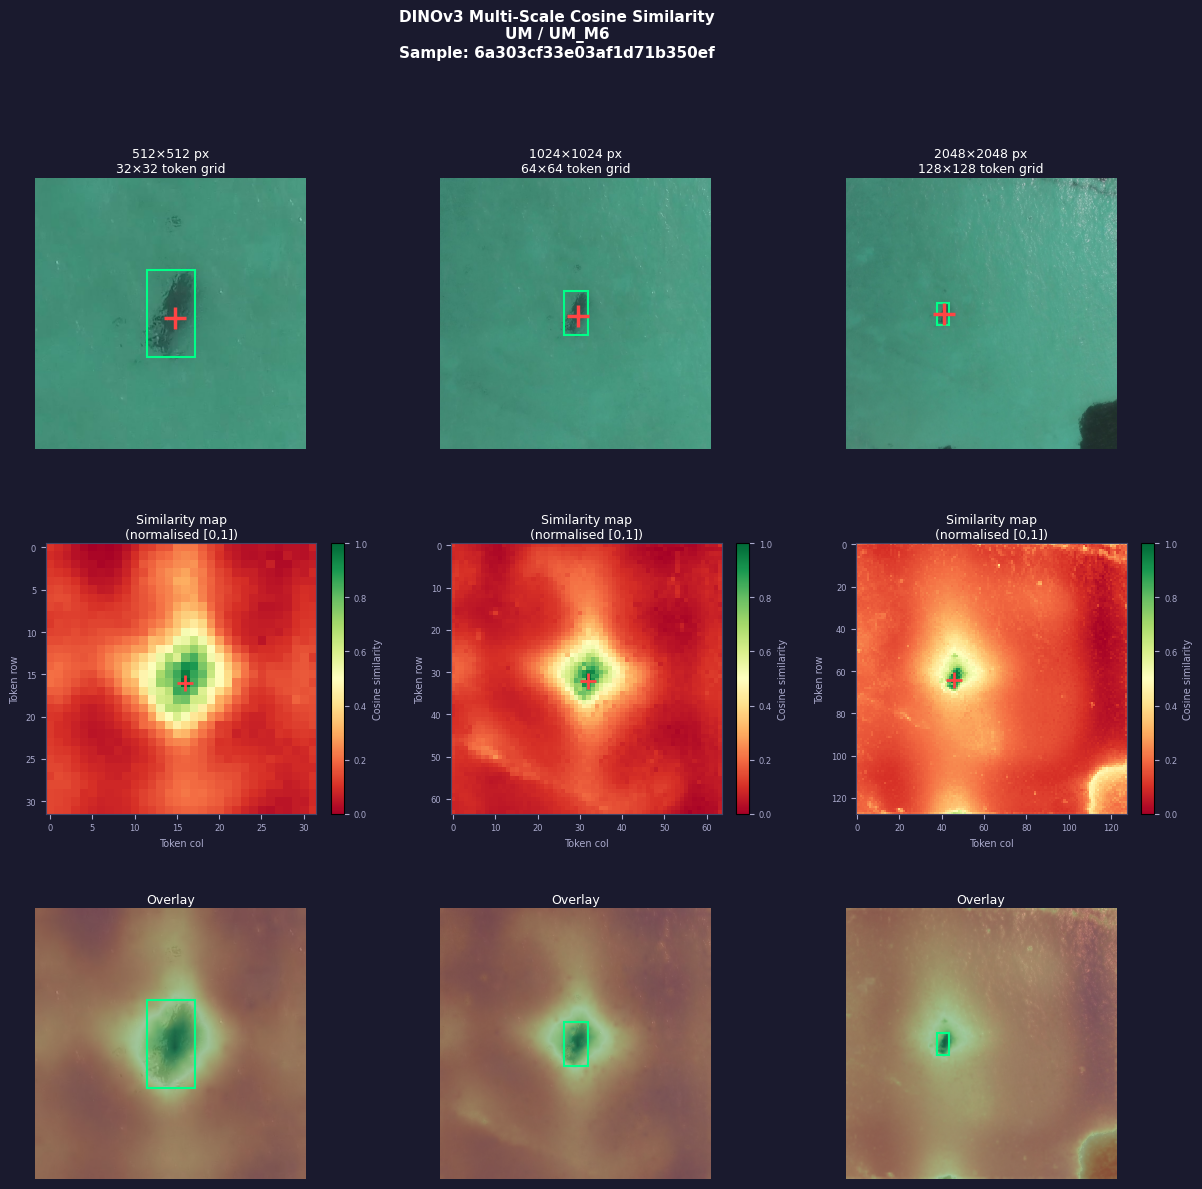

In [24]:

fig = plot_multiscale_similarity(
    dataset    = dataset,
    identifier = "6a303cf33e03af1d71b350ef",
    crop_sizes = CROP_SIZES,       # [512, 1024, 2048]
    use_norm   = True,
    alpha      = 0.50,
    save_path  = "test3_cosine.jpeg",
)

In [ ]:

fig = plot_multiscale_similarity(
    dataset    = dataset,
    identifier = "6a303cf33e03af1d71b350b5",
    crop_sizes = CROP_SIZES,       # [512, 1024, 2048]
    use_norm   = True,
    alpha      = 0.50,
    save_path  = "test2_cosine.jpeg",
)

In [ ]:

fig = plot_multiscale_similarity(
    dataset    = dataset,
    identifier = "6a303cf33e03af1d71b350c4",
    crop_sizes = [512, 1024, 2048],       # [512, 1024, 2048]
    use_norm   = True,
    alpha      = 0.50,
   save_path  = "test_cosine4.jpeg",
)

In [ ]:
#  Call it
# Replace with a real sample_id or filepath from your dataset
fig = plot_multiscale_similarity(
    dataset    = dataset,
    identifier = "6a303cf33e03af1d71b350a9",
    crop_sizes = CROP_SIZES,       # [512, 1024, 2048]
    use_norm   = True,
    alpha      = 0.50,
    save_path  = "test_cosine.jpeg",
)

# Tiling grid schema analysis

In [6]:
from src.tiling import add_roi_grid

In [61]:
nc_dataset  = fo.load_dataset("nc765")

In [25]:
fo.list_datasets()

['FLPLAN', 'flplan200', 'flplanpatches', 'nc765', 'wp125']

In [3]:
dataset = fo.load_dataset("wp125")

In [4]:
dataset

Name:        wp125
Media type:  image
Num samples: 152
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    thumbnail_path:   fiftyone.core.fields.StringField
    roigrid_512_250:  fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    roigrid_1024_250: fiftyone.core.fields.EmbeddedDocumentField

In [5]:
import fiftyone.utils.image as foui


In [66]:
thumbnail_dir = "/share/home/e2406743/dataset/dataset/NC/thumb_dir"
foui.transform_images(
    nc_dataset,
    size=(400, 400),              # fixed 400x400 grid thumbnails
    output_field="thumbnail_path",
    output_dir=thumbnail_dir,
    update_filepaths=True,
)

# Tell the App to use thumbnails in the grid, full image on click
dataset.app_config.media_fields     = ["filepath", "thumbnail_path"]
dataset.app_config.grid_media_field = "thumbnail_path"
dataset.app_config.media_fallback   = True   # fall back to filepath if thumb missing
dataset.save()

 100% |█████████████████| 716/716 [6.6s elapsed, 0s remaining, 219.1 samples/s]      


In [67]:
nc_dataset

Name:        nc765
Media type:  image
Num samples: 716
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    thumbnail_path:   fiftyone.core.fields.StringField

In [5]:
import sys
%load_ext autoreload
%autoreload 2

In [60]:
fo.delete_dataset("nc765")

In [6]:
from src.relabel_calf import relabel_calves, relabel_calves_wp

In [28]:
dataset

Name:        wp125
Media type:  image
Num samples: 152
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    thumbnail_path:   fiftyone.core.fields.StringField
    roigrid_512_250:  fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    roigrid_1024_250: fiftyone.core.fields.EmbeddedDocumentField

In [8]:
relabel_calves_wp(
    dataset=dataset,
    xlsx_path="/share/home/e2406743/dataset/dataset/WP/dugong_environmental_variables_WP.xlsx",
    field_ground="ground_truth",
    new_field="ground_truthv2",
)

Matching mode: (cx, cy) centroid-only -- width/height NOT in metadata
Loaded 3615 rows across 2039 unique label files.
 100% |█████████████████| 152/152 [7.7s elapsed, 0s remaining, 27.4 samples/s]      

Done.
  New field created       : 'ground_truthv2'
  Samples with relabeling : 77
  Detections relabeled     : 79
  Samples copied unchanged (no metadata match): 0
  Samples with empty/None 'ground_truth' (skipped entirely): 0

  --- First 4 examples for debugging ---
    [NO_COORD_MATCH (closest diff=0.41142)] stem='MAN_P4P_FRIWEN_M53_F3_GSP_DJI_0005-66b0f7a597325_53'  n_detections=1  n_csv_rows=1
    [NO_COORD_MATCH (closest diff=0.13623)] stem='MAN_P4P_FRIWEN_M53_F3_GSP_DJI_0005-66b0f7a597325_56'  n_detections=1  n_csv_rows=1
    [NO_COORD_MATCH (closest diff=0.19565)] stem='MAN_P4P_FRIWEN_M53_F3_GSP_DJI_0005-66b0f7a597325_55'  n_detections=1  n_csv_rows=1
    [NO_COORD_MATCH (closest diff=0.29784)] stem='MAN_P4P_FRIWEN_M53_F3_GSP_DJI_0005-66b0f7a597325_54'  n_detections=1  n_csv_r

In [ ]:
session = fo.launch_app(dataset, auto=False,port=5151)

Session launched. Run `session.show()` to open the App in a cell output.


In [72]:
import pandas as pd
df = pd.read_csv("/share/home/e2406743/dataset/dataset/NC/dugong_environmental_variables_NC.csv")

In [9]:
dataset.count_values("ground_truthv2.detections.label")

{'Dugong': 183, 'calf': 79}

In [92]:
nc_dataset.first()

<Sample: {
    'id': '6a317f84cb12dcb400c28466',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
    'tags': [],
    'metadata': <ImageMetadata: {
        'size_bytes': 712381,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 6, 16, 16, 53, 24, 341000),
    'last_modified_at': datetime.datetime(2026, 6, 16, 17, 23, 44, 36000),
    'region': 'NC',
    'mission_name': 'Flight_226',
    'parent_name': 'Flight_226',
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '6a317f82cb12dcb400c2768c',
                'attributes': {},
                'tags': [],
                'label': 'dugong',
                'bounding_box': [
                    0.9090236686390533,
                    0.29539473684210527,
                    0.01257396449704142,

In [50]:
fo.delete_dataset("dugong")

In [49]:
fo.list_datasets()

['FLPLAN', 'dugong', 'flplan200', 'flplanpatches', 'nc765', 'wp125']

In [48]:
nc_dataset.values("filepath")

['/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_96.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_93.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_94.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_95.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_218/images/GH054218-61922879d59df_805.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_218/images/GH074218-619229147431c_1326.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_218/images/GH034218-619227cbdc2f7_1037.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_218/images/GH054218-61922879d59df_1980.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_218/images/GH054218-61922879d59df_807.jpeg',
 '/share/home/e2406743/dataset/dataset/NC/Flight_218/images/GH

In [8]:
dataset = fo.load_dataset("wp125")

In [35]:
add_roi_grid(dataset, 
             field_name = "roigrid_2048_250",
                tile_size=2048, 
                overlap=250)

Adding 'roigrid_2048_250' (tile=2048px, overlap=250px) ...
 100% |█████████████████| 152/152 [4.6s elapsed, 0s remaining, 30.6 samples/s]      
  'roigrid_2048_250' added to 152 samples (12 tiles/image at this resolution).


In [36]:
sample = dataset.first()
sample.field_names

('id',
 'filepath',
 'tags',
 'metadata',
 'created_at',
 'last_modified_at',
 'region',
 'mission_name',
 'parent_name',
 'ground_truth',
 'thumbnail_path',
 'roigrid_512_250',
 'roigrid_1024_250',
 'roigrid_2048_250')

In [42]:
len(sample.roigrid_512_250.detections)

294

In [43]:
len(sample.roigrid_1024_250.detections)

40

In [44]:
len(sample.roigrid_2048_250.detections)

12

In [31]:
dataset.delete_sample_fields(["roi_grid","roigrid_2048_250","roigrid_1024_250","roigrid_512_250"])

In [20]:
dataset.count('roi_grid.detections')

2486

In [37]:
dataset.count('roigrid_512_250.detections')

24720

In [38]:
dataset.count('roigrid_1024_250.detections')

3128

In [ ]:
dataset.count('roigrid_2048_250.detections')

996

In [41]:
len(sample.roigrid_512_250.detections)

294

# Embeddings at the full image 

In [4]:
import fiftyone.zoo as foz
import fiftyone.brain as fob
from fiftyone import ViewField as F
import fiftyone.operators as foo
from fiftyone.utils.huggingface import load_from_hub
import cv2
import numpy as np
import fiftyone.brain as fob
import fiftyone.utils.transformers as fout
import numpy as np 

In [5]:
fo.list_datasets()

['FLPLAN', 'flplan200', 'flplanpatches', 'nc765', 'wp125']

In [37]:
dataset = fo.load_dataset("FLPLAN")

In [38]:
dataset

Name:        FLPLAN
Media type:  image
Num samples: 83
Persistent:  True
Tags:        []
Sample fields:
    id:                                     fiftyone.core.fields.ObjectIdField
    filepath:                               fiftyone.core.fields.StringField
    tags:                                   fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                               fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                             fiftyone.core.fields.DateTimeField
    last_modified_at:                       fiftyone.core.fields.DateTimeField
    region:                                 fiftyone.core.fields.StringField
    mission_name:                           fiftyone.core.fields.StringField
    parent_name:                            fiftyone.core.fields.StringField
    roi_grid:                               fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detection

In [8]:
from transformers import AutoImageProcessor, AutoModel

MODEL_ID  = "facebook/dinov3-vitl16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model     = AutoModel.from_pretrained(MODEL_ID)



Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

In [10]:
# Change resize target from 224x224 to e.g. 448x448 or 512x512
processor.size = {"height": 512, "width": 512}
# processor.do_resize stays True -- we WANT resizing here, just to a bigger target

print(processor.size)  # confirm: {'height': 448, 'width': 448}

{'height': 512, 'width': 512}


In [11]:
processor

DINOv3ViTImageProcessorFast {
  "data_format": "channels_first",
  "default_to_square": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "DINOv3ViTImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 512,
    "width": 512
  }
}

In [39]:
## Here I compute the embedding for the full image 
embeddings = dataset.compute_embeddings(
    model,
    embeddings_field=None,
    num_workers =2,
    batch_size=4,
    progress=True,  
)

 100% |███████████████████| 83/83 [22.4s elapsed, 0s remaining, 4.5 samples/s]    


In [33]:
embeddings.shape

(152, 1024)

In [22]:
from pathlib import Path
import os

In [40]:
sample_ids_list = np.array(dataset.values("id"))
stem_list = np.array([Path(f).stem for f in dataset.values("filepath")])


In [41]:
stem_list.shape

(83,)

In [42]:
folder_emb = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3"
out_file = "um_flplan_full_embeddings.npz"

np.savez_compressed(
    os.path.join(folder_emb,out_file),
    embeddings = embeddings,
    sample_ids = sample_ids_list,
    stem_filepath = stem_list
)

# patch embeddings

In [ ]:
# ── Object-level (patch) embedding extraction for ONE dataset ──────────────
# NOTE: these are PATCH/OBJECT embeddings (one per ground_truth detection,
# i.e. per dugong/calf crop) -- NOT full-image embeddings. Each row in the
# saved .npz corresponds to exactly one fo.Detection, uniquely identified
# by that detection's own .id (robust even if detection order changes).

import numpy as np

PATCHES_FIELD = "ground_truth"
OUTPUT_NPZ    = "nc_object_embeddings.npz"   # <- rename per dataset (nc/wp/um)
BRAIN_KEY     = "object_emb_dinov3_tsne_nc"  # <- rename per dataset

# Step 1: compute OBJECT (patch) embeddings, NOT written to the dataset
# Returns: {sample_id: np.ndarray(num_detections_in_that_sample, dim)}
object_embeddings = dataset.compute_patch_embeddings(
    model,
    patches_field=PATCHES_FIELD,
    num_workers=0,
    progress=True,
    # embeddings_field intentionally omitted -> nothing written to MongoDB
)

# Step 2: flatten to (total_objects, dim), join key = each Detection's own .id
detection_ids, sample_ids, rows = [], [], []
for sample_id, arr in object_embeddings.items():
    detections = dataset[sample_id][PATCHES_FIELD].detections
    assert len(detections) == arr.shape[0], (
        f"Mismatch for sample {sample_id}: {len(detections)} detections "
        f"vs {arr.shape[0]} embedding rows"
    )
    for det, vec in zip(detections, arr):
        detection_ids.append(det.id)     # unique per-object join key
        sample_ids.append(sample_id)     # which image this object came from
        rows.append(vec)

object_embeddings_flat = np.stack(rows, axis=0)         # (total_objects, dim)
detection_ids = np.array(detection_ids)                  # join key -> ground_truth.detections[i].id
sample_ids    = np.array(sample_ids)                     # which sample/image

np.savez_compressed(
    OUTPUT_NPZ,
    object_embeddings=object_embeddings_flat,   # (total_objects, dim) float32
    detection_ids=detection_ids,                # unique per-object ID (join key)
    sample_ids=sample_ids,                      # parent image's sample_id
)
print(f"Saved {object_embeddings_flat.shape[0]} object embeddings "
      f"({object_embeddings_flat.shape[1]}-dim) -> '{OUTPUT_NPZ}'")

# Step 3: visualization, reusing the SAME in-memory dict (not the npz)
fob.compute_visualization(
    dataset,
    patches_field=PATCHES_FIELD,
    embeddings=object_embeddings,   # dict, keyed by sample_id -> reused directly
    method="tsne",
    brain_key=BRAIN_KEY,
    create_index=True,
    seed=42,
    max_iter=2000,
    progress=True,
)
print(f"Visualization stored under brain_key '{BRAIN_KEY}'.")

# Compute Visualization

 np.saved

In [11]:
fo.list_datasets()

['FLPLAN', 'flplan200', 'flplanpatches', 'nc765', 'wp125']

In [50]:
dataset = fo.load_dataset("FLPLAN")
dataset

Name:        FLPLAN
Media type:  image
Num samples: 83
Persistent:  True
Tags:        []
Sample fields:
    id:                                     fiftyone.core.fields.ObjectIdField
    filepath:                               fiftyone.core.fields.StringField
    tags:                                   fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                               fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                             fiftyone.core.fields.DateTimeField
    last_modified_at:                       fiftyone.core.fields.DateTimeField
    region:                                 fiftyone.core.fields.StringField
    mission_name:                           fiftyone.core.fields.StringField
    parent_name:                            fiftyone.core.fields.StringField
    roi_grid:                               fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detection

In [51]:
dataset.count_values("mission_name")

{'UM': 83}

In [36]:
dataset.count_values("parent_name")

{'Flight_197': 50,
 'Flight_233': 6,
 'Flight_226': 5,
 'Flight_212': 36,
 'Flight_215': 37,
 'Flight_232': 23,
 'Flight_234': 2,
 'Flight_199': 8,
 'Flight_213': 41,
 'Flight_235': 4,
 'Flight_209': 83,
 'Flight_231': 12,
 'Flight_214': 19,
 'Flight_195': 6,
 'Flight_225': 2,
 'Flight_200': 10,
 'Flight_196': 63,
 'Flight_207': 128,
 'Flight_220': 20,
 'Flight_205': 9,
 'Flight_211': 17,
 'Flight_218': 22,
 'Flight_198': 73,
 'Flight_222': 17,
 'Flight_219': 23}

In [33]:
dataset.count_values("parent_name")

{'FRIWEN_M8': 21,
 'FRIWEN_M12': 11,
 'GAM_M2': 11,
 'FRIWEN_M53': 4,
 'GAM_M10': 4,
 'FRIWEN_M19': 3,
 'GAM_M1': 12,
 'MANTASANDY_M5': 3,
 'UM_M6': 9,
 'UM_M1': 14,
 'UM_M3': 4,
 'UM_M5': 23,
 'FRIWEN_M11': 24,
 'UM_M2': 9}

In [13]:
dataset

Name:        nc765
Media type:  image
Num samples: 716
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    region:           fiftyone.core.fields.StringField
    mission_name:     fiftyone.core.fields.StringField
    parent_name:      fiftyone.core.fields.StringField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    thumbnail_path:   fiftyone.core.fields.StringField
    ground_truthv2:   fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)

In [16]:
dataset.count_values("region")

{'NC': 716}

In [24]:
dataset.select_fields("region")

Dataset:     nc765
Media type:  image
Num samples: 716
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    region:           fiftyone.core.fields.StringField
View stages:
    1. SelectFields(field_names=['region'], meta_filter=None)

In [5]:

def load_and_tag(npz_path, region_name, dataset_name, field_name_subregion):
    """Load the npz files and provide associate metadata query from fiftyone.dataset

    args:
        dataset_name :Name of fiftyone mongod dataset
        field_name_subgion: Name of the field to retrieve the subregion
    """

    data = np.load(npz_path)
    n = data["embeddings"].shape[0]
    sample_ids = data["sample_ids"]

    # Re-derive subregion (mission_name) by querying FiftyOne directly,
    dataset = fo.load_dataset(dataset_name)
    print(dataset.name)
    ids_list = np.array(dataset.values("id"))
    query_region = np.array(dataset.values(field_name_subregion))

    assert all(ids_list == sample_ids), f"Problem of alignment of ids. BIG ISSUES"


    return {
        "embeddings": data["embeddings"],
        "sample_ids": sample_ids,
       # "stems":      data["stems_filepaths"],
        "region":     np.full(n, region_name),
        "subregion":  query_region,
    }


In [6]:
emb_nc = load_and_tag("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/nc_full_embeddings.npz",
                      region_name="NC",
                      dataset_name="nc765",
                      field_name_subregion="region")

emb_wp = load_and_tag(npz_path="/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/wp_full_embeddings.npz",
                      region_name="WP", 
                      dataset_name="wp125",
                      field_name_subregion="mission_name")

emb_um = load_and_tag("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/embeddings_dinov3/um_flplan_full_embeddings.npz",
                      "UM", 
                      "FLPLAN",
                      "mission_name")


nc765
wp125
FLPLAN


In [7]:
## join them
sources = [emb_nc, emb_wp, emb_um]
joint_embeddings = np.concatenate([s["embeddings"] for s in sources], axis=0)
joint_sample_ids = np.concatenate([s["sample_ids"] for s in sources], axis=0)
joint_region     = np.concatenate([s["region"]     for s in sources], axis=0)
joint_subregion  = np.concatenate([s["subregion"]  for s in sources], axis=0)

print(f"Joint embeddings: {joint_embeddings.shape}")
print(f"Region counts:    {dict(zip(*np.unique(joint_region, return_counts=True)))}")
print(f"Subregion counts: {dict(zip(*np.unique(joint_subregion, return_counts=True)))}")

Joint embeddings: (951, 1024)
Region counts:    {np.str_('NC'): np.int64(716), np.str_('UM'): np.int64(83), np.str_('WP'): np.int64(152)}
Subregion counts: {np.str_('FRIWEN'): np.int64(63), np.str_('GAM'): np.int64(27), np.str_('MANTASANDY'): np.int64(3), np.str_('NC'): np.int64(716), np.str_('UM'): np.int64(142)}


In [45]:
import sys
%load_ext autoreload
%autoreload 2

# import sys
# sys.path.append("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/src")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
plt.style.available


['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [31]:
import sys
%load_ext autoreload
%autoreload 2

# import sys
# sys.path.append("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/src")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
joint_embeddings_norm = normalize(joint_embeddings, norm="l2")
 
pca_2d = PCA(n_components=5)
coords_2d_pca = pca_2d.fit_transform(joint_embeddings_norm)
 
 
pca_2d.explained_variance_ratio_

array([0.16408738, 0.13287127, 0.0703226 , 0.06058995, 0.04302573],
      dtype=float32)

/share/home/e2406743/.conda/envs/fifty/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


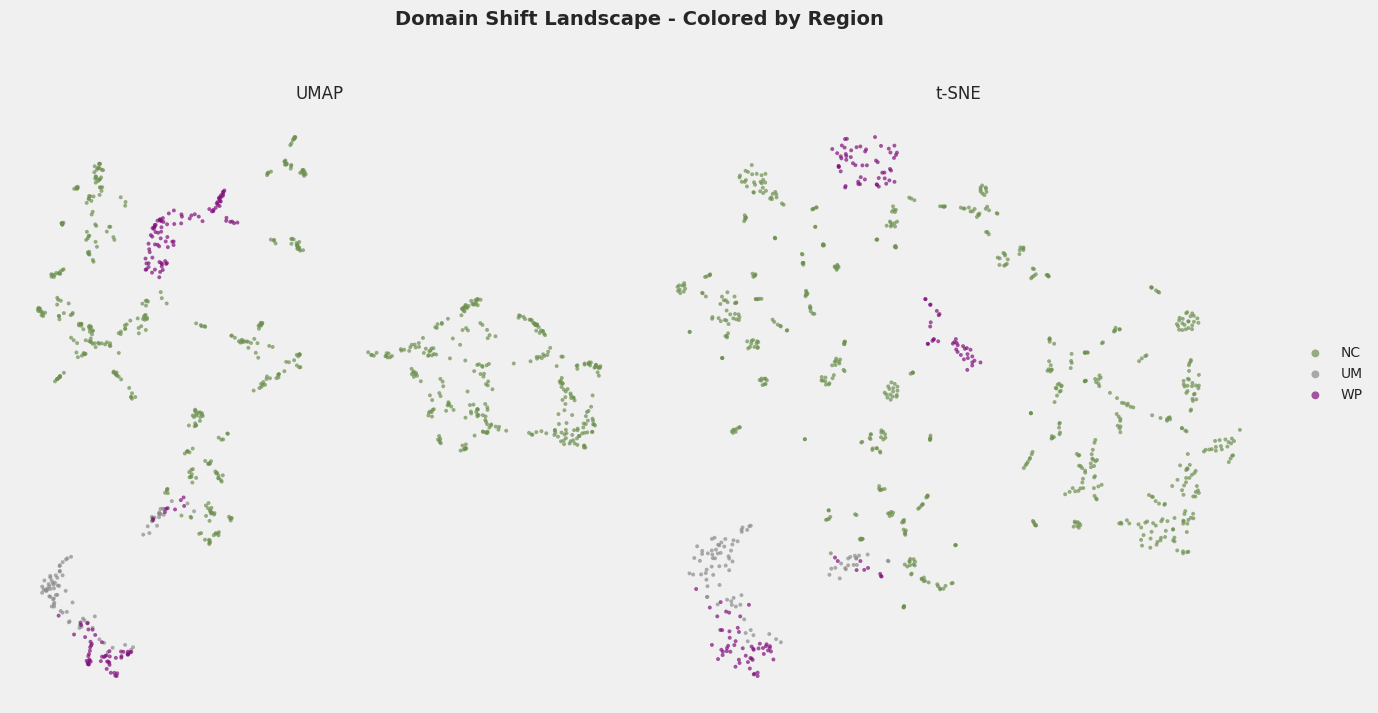

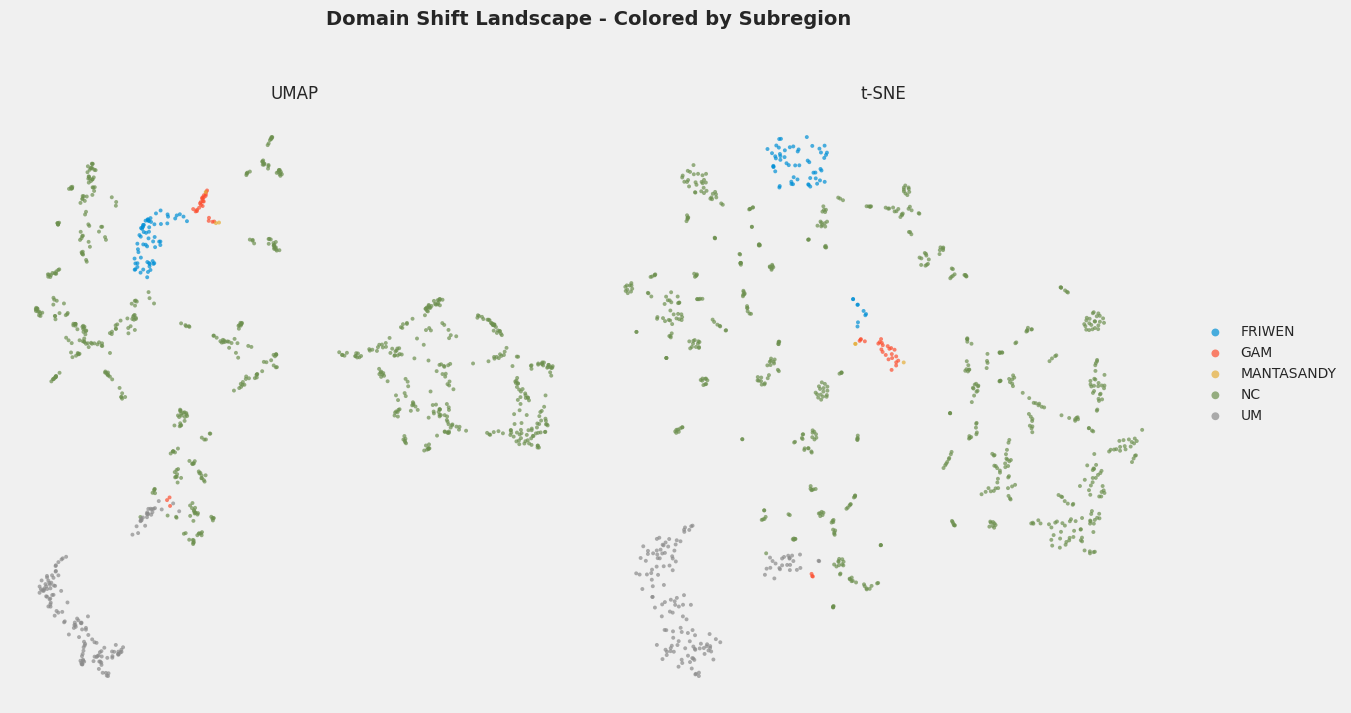

In [36]:
# ── Compute the three 2D projections on the joint embeddings ────────────────
# (Normalise first -- cosine-based methods and PCA both benefit from this)
from sklearn.preprocessing import normalize
 
joint_embeddings_norm = normalize(joint_embeddings, norm="l2")
 
pca_2d = PCA(n_components=2)
coords_2d_pca = pca_2d.fit_transform(joint_embeddings_norm)
 
reducer = umap.UMAP(
    n_neighbors=30, n_epochs=500, min_dist=0.2,
    metric="cosine", init="pca", random_state=42,
)
coords_2d_umap = reducer.fit_transform(joint_embeddings_norm)
 
tsne = TSNE(
    n_components=2, random_state=0, perplexity=30,
    metric="cosine", init="pca",
)
coords_2d_tsne = tsne.fit_transform(joint_embeddings_norm)
 
# ── Plot, colored by region ───────────────────────────────────────────────
fig_region = plot_domain_shift_landscape(
    coords_2d_pca, coords_2d_umap, coords_2d_tsne,
    color_labels=joint_region,
    figsize=(13,7),
    title="Domain Shift Landscape - Colored by Region",
)
plt.show()
 
# ── Plot, colored by subregion ────────────────────────────────────────────
fig_subregion = plot_domain_shift_landscape(
    coords_2d_pca, coords_2d_umap, coords_2d_tsne,
    color_labels=joint_subregion,
    figsize=(12,7),
    title="Domain Shift Landscape - Colored by Subregion",
)
plt.show()

## Plot with different style 

In [46]:
import sys
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [78]:
print(plt.rcParams['axes.facecolor'])   # ggplot's light gray, e.g. '#E5E5E5' or similar
print(plt.style.available)               # confirm 'ggplot' is a valid name in this matplotlib version

#E5E5E5
['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [48]:

# Apply the ggplot style globally for the session
# (Change this freely to test other styles, e.g. 'bmh', 'fivethirtyeight',
#  'tableau-colorblind10', 'Solarize_Light2' -- see plt.style.available)
plt.style.use('seaborn-v0_8-colorblind')
 
# Every label that could ever appear across any plot (region OR subregion)
# is registered here ONCE, so the same label always maps to the same
# position in the color cycle -- guaranteeing e.g. "NC" gets the same
# color in every figure, regardless of which subset of labels is present
# in a given call, and regardless of which style is currently active.
ALL_REGION_LABELS    = ["NC", "WP", "UM"]
ALL_SUBREGION_LABELS = ["FRIWEN", "GAM", "MANTASANDY", "UM"]   # extend as needed
_ALL_LABELS = sorted(set(ALL_REGION_LABELS) | set(ALL_SUBREGION_LABELS))
 
 
def _build_palette_from_active_style(labels):
    """
    Builds a {label: color} mapping by pulling colors directly from the
    CURRENTLY ACTIVE style's axes.prop_cycle, rather than hardcoding a
    colormap like tab10. This means the palette automatically follows
    whatever style is active via plt.style.use(...) at call time -- so
    switching styles between cells changes the palette too, without
    needing to touch this function.
 
    If there are more labels than colors in the cycle, colors repeat
    (wrap around) rather than erroring, since some styles (e.g. ggplot)
    have fewer built-in colors than others (e.g. tab10-based cycles).
    """
    cycle_colors = [d["color"] for d in plt.rcParams["axes.prop_cycle"]]
    return {
        lab: cycle_colors[i % len(cycle_colors)]
        for i, lab in enumerate(labels)
    }
 
 
# Built fresh from whichever style is active at import time. Call
# _build_palette_from_active_style(_ALL_LABELS) again after switching
# styles if you want GLOBAL_PALETTE to reflect the new style too.
GLOBAL_PALETTE = _build_palette_from_active_style(_ALL_LABELS)

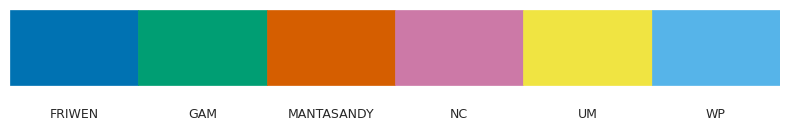

In [54]:
fig, ax = plt.subplots(figsize=(8, 1.5))

for i, (label, color) in enumerate(GLOBAL_PALETTE.items()):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
    ax.text(i + 0.5, -0.3, label, ha="center", va="top", fontsize=9)

ax.set_xlim(0, len(GLOBAL_PALETTE))
ax.set_ylim(-0.6, 1)
ax.axis("off")
#ax.set_title(f"Palette ({current_style_name})", fontsize=10)
plt.tight_layout()
plt.show()

In [42]:
GLOBAL_PALETTE

{'FRIWEN': '#E24A33',
 'GAM': '#348ABD',
 'MANTASANDY': '#988ED5',
 'NC': '#777777',
 'UM': '#FBC15E',
 'WP': '#8EBA42'}

In [55]:
print(plt.rcParams['axes.facecolor'])   # ggplot's light gray, e.g. '#E5E5E5' or similar
print(plt.style.available)               # confirm 'ggplot' is a valid name in this matplotlib version

#E5E5E5
['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


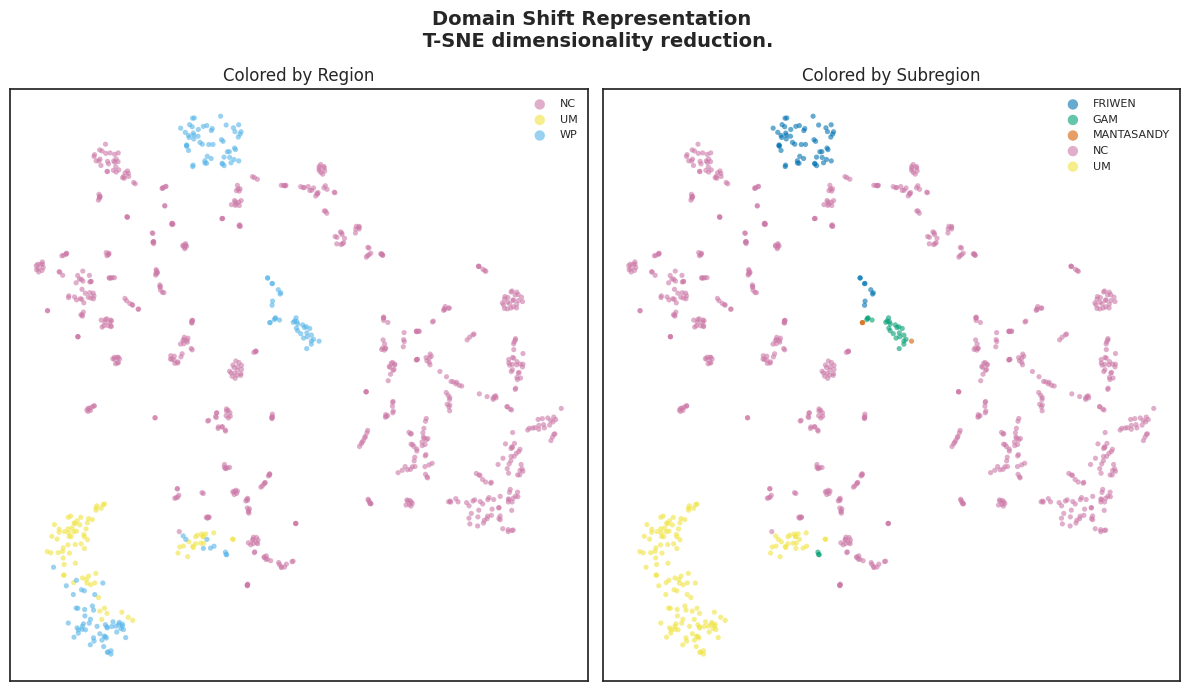

In [67]:
# ── t-SNE only: region (left) vs subregion (right) ──────────────────────────
with plt.style.context('seaborn-v0_8-white'):
    palette = _build_palette_from_active_style(_ALL_LABELS)   # reflects this style only

    fig, axes = plt.subplots(1, 2, figsize=(12, 7))

    for ax, color_labels, panel_title in zip(
        axes, [joint_region, joint_subregion], ["Colored by Region", "Colored by Subregion"]
    ):
        for lab in sorted(set(color_labels)):
            mask = color_labels == lab
            ax.scatter(
                coords_2d_tsne[mask, 0], coords_2d_tsne[mask, 1],
                s=14, alpha=0.6, color=palette[lab], label=lab, edgecolors="none",
            )
        ax.set_title(panel_title, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.legend(fontsize=8, markerscale=2)
        #ax.annotate('figure pixels',xy=(0,0),y=(0, 0))

    fig.suptitle("Domain Shift Representation \n T-SNE dimensionality reduction.", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

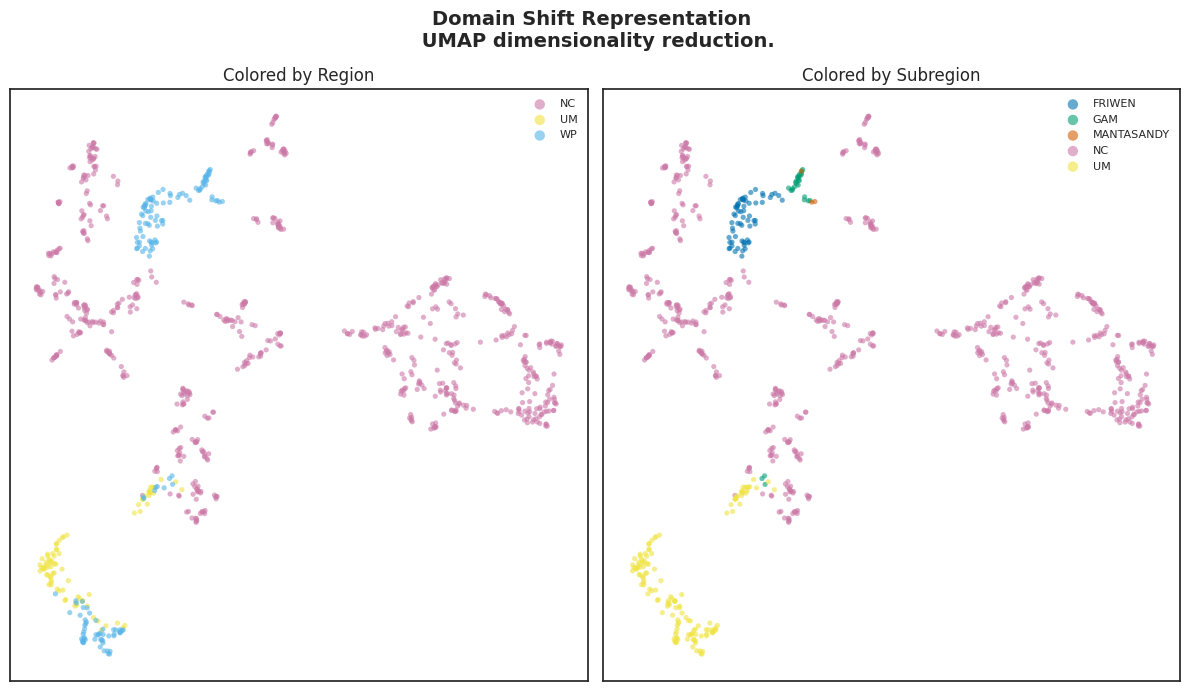

In [68]:
# ── t-SNE only: region (left) vs subregion (right) ──────────────────────────
with plt.style.context('seaborn-v0_8-white'):
    palette = _build_palette_from_active_style(_ALL_LABELS)   # reflects this style only

    fig, axes = plt.subplots(1, 2, figsize=(12, 7))

    for ax, color_labels, panel_title in zip(
        axes, [joint_region, joint_subregion], ["Colored by Region", "Colored by Subregion"]
    ):
        for lab in sorted(set(color_labels)):
            mask = color_labels == lab
            ax.scatter(
                coords_2d_umap[mask, 0], coords_2d_umap[mask, 1],
                s=14, alpha=0.6, color=palette[lab], label=lab, edgecolors="none",
            )
        ax.set_title(panel_title, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.legend(fontsize=8, markerscale=2)
        #ax.annotate('figure pixels',xy=(0,0),y=(0, 0))

    fig.suptitle("Domain Shift Representation \n UMAP dimensionality reduction.", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [73]:
# ── 3D UMAP, colored by subregion, hover shows region too ──────────────────
import plotly.express as px
import pandas as pd
import umap

# Fit UMAP in 3D (separate from the earlier 2D fit)
reducer_3d = umap.UMAP(
    n_neighbors=45, n_epochs=500, min_dist=0.25,
    metric="cosine", init="pca", n_components=3, random_state=23,
)
coords_3d_umap = reducer_3d.fit_transform(joint_embeddings_norm)

# Build a small dataframe so plotly can use named columns for color/hover
df_plot = pd.DataFrame({
    "x": coords_3d_umap[:, 0],
    "y": coords_3d_umap[:, 1],
    "z": coords_3d_umap[:, 2],
    "subregion": joint_subregion,
    "region": joint_region,
})

fig = px.scatter_3d(
    df_plot,
    x="x", y="y", z="z",
    color="subregion",
    hover_data={"region": True, "x": False, "y": False, "z": False},
    title="3D UMAP - Domain Shift Landscape (colored by subregion)",
    opacity=0.7,
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(
    scene=dict(xaxis_title="UMAP-1", yaxis_title="UMAP-2", zaxis_title="UMAP-3"),
    legend_title_text="Subregion",
)
fig.show()

/share/home/e2406743/.conda/envs/fifty/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



# 5. Tiling grid and positive negative dugong presence

check the file 
```
tiling_export.py
```

6. Tiles Subdataset

Here we create and launch the tiling dataset in a fiftyone instance to see the quality of our dataset and compute the feature extraction with dinov3

In [11]:
from src.create_tile_dataset import create_tile_dataset

dataset = create_tile_dataset(
    path_root="/share/home/e2406743/dataset/tiles_all/nc765",
    name_dataset="nc765_T1024ov224",
)


  Found 2070 images in positive/images/
  Found 3658 images in negative/images/

Adding 5728 tile samples to 'nc765_T1024ov224' ...
 100% |███████████████| 5728/5728 [3.6s elapsed, 0s remaining, 2.2K samples/s]        
Computing metadata...
 100% |███████████████| 5728/5728 [14.1s elapsed, 0s remaining, 404.1 samples/s]      
Done. Dataset 'nc765_T1024ov224' created with 5728 samples.
  type_label counts: {'positive': 2070, 'negative': 3658}


In [13]:
dataset.count_values("ground_truth.detections.label")

{'0': 1367, '1': 7205}

In [14]:

dataset = create_tile_dataset(
    path_root="/share/home/e2406743/dataset/tiles_all/wp125",
    name_dataset="wp125_T1024ov224",
)


  Found 335 images in positive/images/
  Found 2305 images in negative/images/

Adding 2640 tile samples to 'wp125_T1024ov224' ...
 100% |███████████████| 2640/2640 [1.2s elapsed, 0s remaining, 2.3K samples/s]         
Computing metadata...
 100% |███████████████| 2640/2640 [4.2s elapsed, 0s remaining, 621.2 samples/s]      
Done. Dataset 'wp125_T1024ov224' created with 2640 samples.
  type_label counts: {'negative': 2305, 'positive': 335}


In [12]:
session = fo.launch_app(dataset, auto=False, port=5151)

Session launched. Run `session.show()` to open the App in a cell output.
